In [80]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/house_train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [81]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [ ]:
# 결측치 찾기, 많아서 못찾을때 결측치를 가진 컬럼 찾기
tmp = df.isnull().sum()
print(tmp[tmp > 0].sort_values(ascending = False))

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


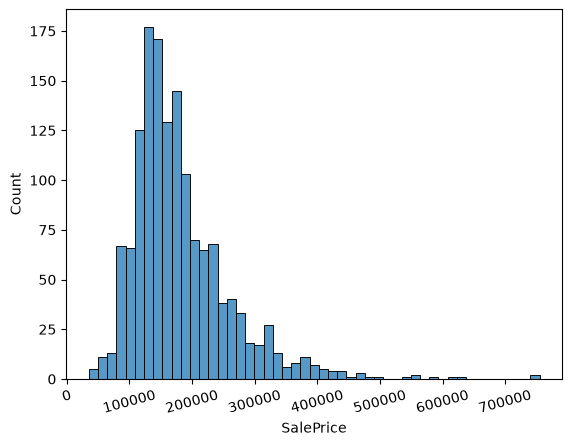

In [83]:
plt.xticks(rotation = 15)
sns.histplot(df["SalePrice"])
plt.show()

<Axes: xlabel='SalePrice', ylabel='Count'>

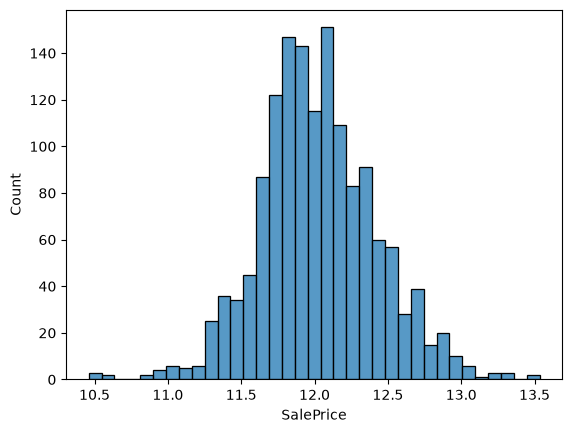

In [84]:
# 원값에 +1을 한 후에 로그를 씌우는 것, 0에 로그하면 무한대
# 스케일작업 = 분포를 고르게 하기 위함
log_SalePrice = np.log1p(df["SalePrice"])
sns.histplot(log_SalePrice)

In [85]:
df["Id"].value_counts()

Id
1       1
2       1
3       1
4       1
5       1
       ..
1456    1
1457    1
1458    1
1459    1
1460    1
Name: count, Length: 1460, dtype: int64

In [86]:
df["FireplaceQu"].value_counts()

FireplaceQu
Gd    380
TA    313
Fa     33
Ex     24
Po     20
Name: count, dtype: int64

In [87]:
# PoolQC          1453
# MiscFeature     1406
# Alley           1369
# Fence           1179
# MasVnrType       872
# FireplaceQu      690

drop_cols = ["Id", "PoolQC", "MiscFeature", "Alley", "Fence", "MasVnrType", "FireplaceQu"]

In [88]:
# 결측치가 많은 칼럽 드랍
df.drop(drop_cols, axis=1, inplace=True)

# 숫자칼럼의 경우 결측치를 평균으로 대체 / 빅분기 실기에서 코드 사용
num_cols = df.dtypes[df.dtypes != "str"].index

# 데이터타입 : Object의 경우 여전히 결측치 남아 있음
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

In [89]:
print(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))

GarageQual      81
GarageCond      81
GarageFinish    81
GarageType      81
BsmtFinType2    38
BsmtExposure    38
BsmtCond        37
BsmtQual        37
BsmtFinType1    37
Electrical       1
dtype: int64


In [90]:
y = df["SalePrice"]
X = df.drop(["SalePrice"], axis = 1)

X_dum = pd.get_dummies(X)

X_dum.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,False,False,False,True,False,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,False,False,False,True,False,False,False,False,True,False
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,False,False,False,True,False,False,False,False,True,False
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,False,False,False,True,True,False,False,False,False,False
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,False,False,False,True,False,False,False,False,True,False


In [91]:
X_train, X_val, y_train, y_val = train_test_split(X_dum,
                                                    y,
                                                    test_size = 0.3,
                                                    random_state = 42)

print(X_train.shape)
print(y_train.shape)

(1022, 266)
(1022,)


In [92]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

df2 = pd.read_csv("../data/house_test.csv")

def get_model_cv_prediction(model, X_data, y_target):
    neg_mse_score = cross_val_score(model,
                                    X_data,
                                    y_target,
                                    scoring = "neg_mean_squared_error",
                                    cv = 5)

    rmse_scores = np.sqrt(-1 * neg_mse_score)
    avg_rmse = np.mean(rmse_scores)

    print(model.__class__.__name__, "RMSE", round(avg_rmse, 4))
    return avg_rmse

In [93]:
y_log = np.log1p(y)

X_train, X_val, y_train, y_val = train_test_split(X_dum,
                                                  y_log,
                                                  test_size = 0.3,
                                                  random_state = 42)

print(X_train.shape)
print(y_train.shape)

(1022, 266)
(1022,)


In [94]:
xgb_reg = XGBRegressor(n_estimators = 1000,
                   learning_rate = 0.05,
                   subsample = 0.8,
                   colsample_bytree = 0.8,
                   random_state = 42)

lgb_reg = LGBMRegressor(n_estimators = 1000,
                    learning_rate = 0.05,
                    subsample = 0.8,
                    colsample_bytree = 0.8,
                    random_state = 42)

print(xgb_reg)
print(lgb_reg)

models = [xgb_reg, lgb_reg]

for model in models:
    get_model_cv_prediction(model, X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)
LGBMRegressor(colsample_bytree=0.8, learning_rate=0.05, n_estimators=1000,
              random_state=42, subsample=0.8)
XGBRegressor RMSE 0.1402
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-cho

In [95]:
for model in models:
    model.fit(X_train, y_train)
    pred_log = model.predict(X_val)

    pred = np.expm1(pred_log)
    y_val_rt = np.expm1(y_val)

    mse = ((y_val_rt - pred)** 2).mean()
    rmse = np.sqrt(mse)

    print(f"{model.__class__.__name__} Test RMSE: {rmse:,.2f}")

XGBRegressor Test RMSE: 25,244.69
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002127 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3044
[LightGBM] [Info] Number of data points in the train set: 1022, number of used features: 161
[LightGBM] [Info] Start training from score 12.028899
LGBMRegressor Test RMSE: 25,778.86


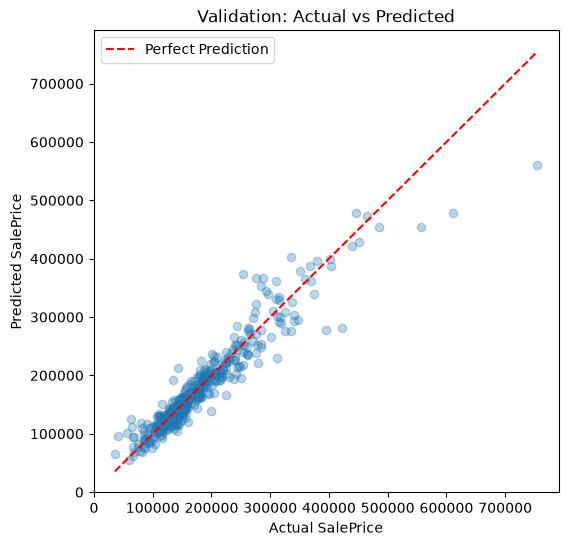

In [96]:
plt.figure(figsize = (6, 6))
plt.scatter(y_val_rt, pred, alpha = 0.3)
plt.plot([y_val_rt.min(), y_val_rt.max()],
         [y_val_rt.min(), y_val_rt.max()],
         "r--",
         label="Perfect Prediction")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Validation: Actual vs Predicted")
plt.legend()
plt.show()

In [ ]:
test_id = df2["Id"]

df2 = df2.drop(drop_cols, axis = 1)

num_cols = df.dtypes[df.dtypes != "str"].index
num_cols = num_cols.drop("SalePrice")

df2[num_cols] = df2[num_cols].fillna(df[num_cols].mean())

In [98]:
test_dum = pd.get_dummies(df2)
test_dum = test_dum.reindex(columns = X_dum.columns, fill_value = 0)

print(X_dum.shape, test_dum.shape)

(1460, 266) (1459, 266)


In [99]:
xgb_final = XGBRegressor(n_estimators = 1000,
                         learning_rate = 0.05,
                         subsample = 0.8,
                         colsample_bytree = 0.8,
                         random_state = 42)

lgb_final = LGBMRegressor(n_estimators = 1000,
                          learning_rate = 0.05,
                          subsample = 0.8,
                          colsample_bytree = 0.8,
                          random_state = 42,
                          verbose = 1)

xgb_final.fit(X_dum, y_log)
lgb_final.fit(X_dum, y_log)

xgb_pred = np.expm1(xgb_final.predict(test_dum))
lgb_pred = np.expm1(lgb_final.predict(test_dum))

pred = (xgb_pred + lgb_pred) / 2

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002181 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3439
[LightGBM] [Info] Number of data points in the train set: 1460, number of used features: 175
[LightGBM] [Info] Start training from score 12.024057


In [ ]:
output = pd.DataFrame({"Id": test_id, "SalePrice": pred})
output.to_csv("output.csv", index=False)
output.head()

KeyError: 'Id'